In [1]:
# Library Imports & GPU Check

In [2]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50V2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import backend as K
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image as PILImage
import seaborn as sns

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.21.0
GPU Available: []


In [3]:
# Paths & Hyperparameters

In [4]:
from pathlib import Path

BASE_DIR    = Path(r"C:\Users\J.Shiva\OneDrive\Attachments\cricket_runout_detection")
SPLIT_DIR   = BASE_DIR / "data" / "split"
RESULTS_DIR = BASE_DIR / "results"
MODELS_DIR  = BASE_DIR / "models"

MOBILENET_SAVE_PATH = MODELS_DIR / "best_model.keras"
RESNET_SAVE_PATH    = MODELS_DIR / "best_model_resnet.keras"

CLASSES    = ["out", "not_out"]
IMG_SIZE   = (224, 224)
BATCH_SIZE = 16
EPOCHS     = 20
LR         = 0.0001

RESULTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

print("Base dir   :", BASE_DIR)
print("Split dir  :", SPLIT_DIR)
print("Image size :", IMG_SIZE)
print("Batch size :", BATCH_SIZE)
print("Epochs     :", EPOCHS)
print("LR         :", LR)

Base dir   : C:\Users\J.Shiva\OneDrive\Attachments\cricket_runout_detection
Split dir  : C:\Users\J.Shiva\OneDrive\Attachments\cricket_runout_detection\data\split
Image size : (224, 224)
Batch size : 16
Epochs     : 20
LR         : 0.0001


In [5]:
# Data Generators

In [6]:
TRAIN_DIR = SPLIT_DIR / "train"
VAL_DIR   = SPLIT_DIR / "val"
TEST_DIR  = SPLIT_DIR / "test"

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary"
)
val_gen = datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary"
)
test_gen = datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary", shuffle=False
)

print("Class indices:", train_gen.class_indices)
print("Train batches:", len(train_gen))
print("Val batches  :", len(val_gen))
print("Test batches :", len(test_gen))

Found 1260 images belonging to 2 classes.
Found 270 images belonging to 2 classes.
Found 270 images belonging to 2 classes.
Class indices: {'not_out': 0, 'out': 1}
Train batches: 79
Val batches  : 17
Test batches : 17


In [7]:
# MobileNetV2 Model Architecture

In [8]:
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.2)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Trainable params    :", sum([tf.size(w).numpy() for w in model.trainable_weights]))
print("Non-trainable params:", sum([tf.size(w).numpy() for w in model.non_trainable_weights]))

Trainable params    : 164097
Non-trainable params: 2257984


In [9]:
# Train MobileNetV2

In [10]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(MOBILENET_SAVE_PATH, monitor="val_accuracy", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks
)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.5126 - loss: 0.8629
Epoch 1: val_accuracy improved from None to 0.67407, saving model to C:\Users\J.Shiva\OneDrive\Attachments\cricket_runout_detection\models\best_model.keras

Epoch 1: finished saving model to C:\Users\J.Shiva\OneDrive\Attachments\cricket_runout_detection\models\best_model.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 26s 246ms/step - accuracy: 0.5500 - loss: 0.7757 - val_accuracy: 0.6741 - val_loss: 0.6035 - learning_rate: 1.0000e-04
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.7011 - loss: 0.5906
Epoch 2: val_accuracy improved from 0.67407 to 0.76667, saving model to C:\Users\J.Shiva\OneDrive\Attachments\cricket_runout_detection\models\best_model.keras

Epoch 2: finished saving model to C:\Users\J.Shiva\OneDrive\Attachments\cricket_runout_detection\models\best_model.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 218ms/step - accuracy: 0.7127 - loss: 0.5665 - val_accuracy: 0.7667 - val_loss: 0.5132 - lea

In [12]:
# MobileNetV2 Training Curves

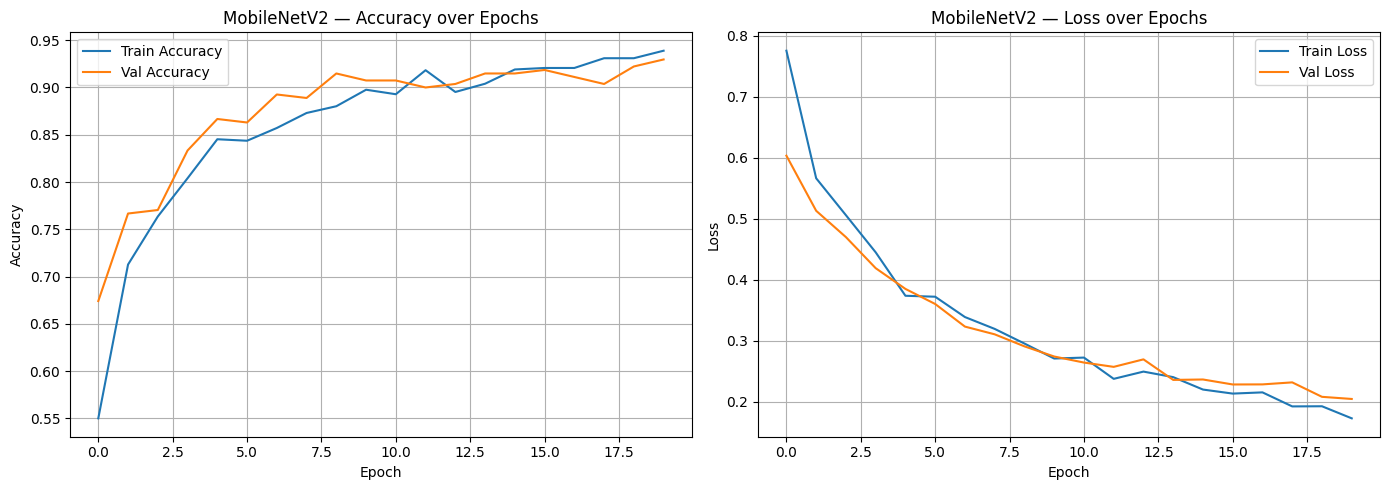

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"], label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("MobileNetV2 — Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["loss"], label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("MobileNetV2 — Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "mobilenet_training_curves.png", dpi=150)
plt.show()

In [14]:
# MobileNetV2 Evaluation on Test Set

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 168ms/step

Classification Report:
              precision    recall  f1-score   support

     not_out       0.93      0.92      0.93       135
         out       0.92      0.93      0.93       135

    accuracy                           0.93       270
   macro avg       0.93      0.93      0.93       270
weighted avg       0.93      0.93      0.93       270



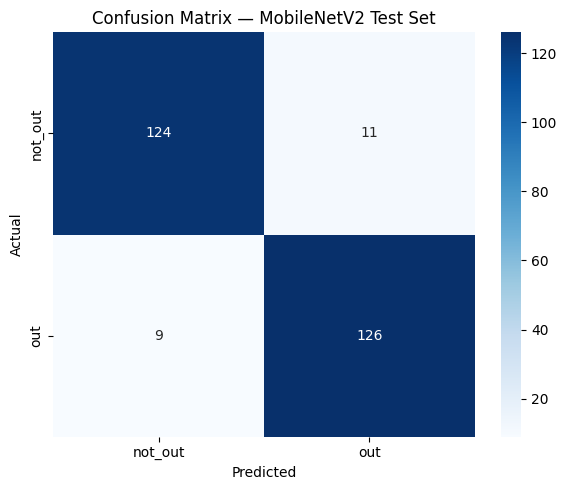

In [15]:
test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["not_out", "out"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["not_out", "out"],
            yticklabels=["not_out", "out"])
plt.title("Confusion Matrix — MobileNetV2 Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "mobilenet_confusion_matrix.png", dpi=150)
plt.show()

In [16]:
# ResNet50V2 Model Architecture

In [17]:
K.clear_session()

base_model_resnet = ResNet50V2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base_model_resnet.trainable = False

x = base_model_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.2)(x)
output = Dense(1, activation="sigmoid")(x)

model_resnet = Model(inputs=base_model_resnet.input, outputs=output)

model_resnet.compile(
    optimizer=Adam(learning_rate=LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Trainable params    :", sum([tf.size(w).numpy() for w in model_resnet.trainable_weights]))
print("Non-trainable params:", sum([tf.size(w).numpy() for w in model_resnet.non_trainable_weights]))


Trainable params    : 262401
Non-trainable params: 23564800


In [ ]:
# Train ResNet50V2

In [18]:
callbacks_resnet = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(RESNET_SAVE_PATH, monitor="val_accuracy", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

history_resnet = model_resnet.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks_resnet
)

Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5267 - loss: 0.8493
Epoch 1: val_accuracy improved from None to 0.75185, saving model to C:\Users\J.Shiva\OneDrive\Attachments\cricket_runout_detection\models\best_model_resnet.keras

Epoch 1: finished saving model to C:\Users\J.Shiva\OneDrive\Attachments\cricket_runout_detection\models\best_model_resnet.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 277s 3s/step - accuracy: 0.5849 - loss: 0.7307 - val_accuracy: 0.7519 - val_loss: 0.5260 - learning_rate: 1.0000e-04
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7363 - loss: 0.5362
Epoch 2: val_accuracy improved from 0.75185 to 0.80000, saving model to C:\Users\J.Shiva\OneDrive\Attachments\cricket_runout_detection\models\best_model_resnet.keras

Epoch 2: finished saving model to C:\Users\J.Shiva\OneDrive\Attachments\cricket_runout_detection\models\best_model_resnet.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 292s 4s/step - accuracy: 0.7405 - loss: 0.5182 - val_accuracy: 0.8000 - val_

In [19]:
# ResNet50V2 Training Curves

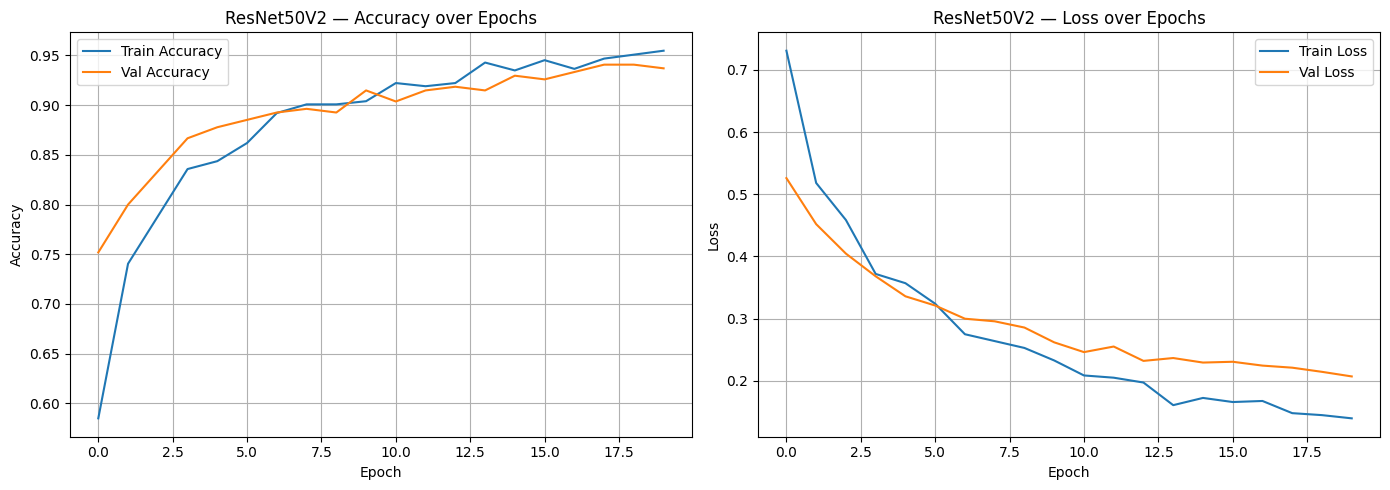

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_resnet.history["accuracy"], label="Train Accuracy")
axes[0].plot(history_resnet.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("ResNet50V2 — Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_resnet.history["loss"], label="Train Loss")
axes[1].plot(history_resnet.history["val_loss"], label="Val Loss")
axes[1].set_title("ResNet50V2 — Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "resnet_training_curves.png", dpi=150)
plt.show()

In [21]:
# ResNet50V2 Evaluation on Test Set

17/17 ━━━━━━━━━━━━━━━━━━━━ 16s 819ms/step

Classification Report — ResNet50V2:
              precision    recall  f1-score   support

     not_out       0.92      0.98      0.95       135
         out       0.98      0.92      0.95       135

    accuracy                           0.95       270
   macro avg       0.95      0.95      0.95       270
weighted avg       0.95      0.95      0.95       270



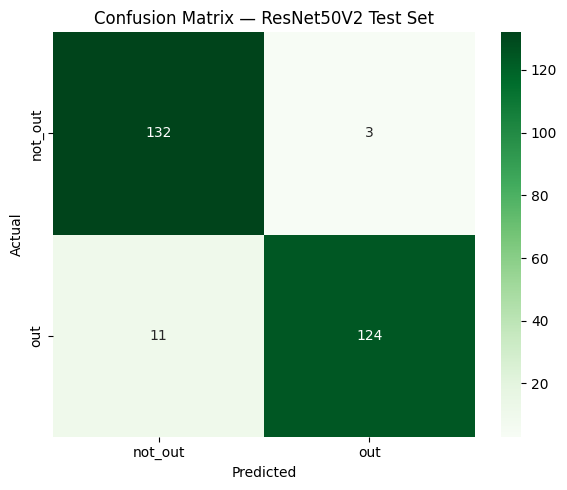

In [22]:
test_gen.reset()
y_pred_probs_resnet = model_resnet.predict(test_gen, verbose=1)
y_pred_resnet = (y_pred_probs_resnet > 0.5).astype(int).flatten()
y_true = test_gen.classes

print("\nClassification Report — ResNet50V2:")
print(classification_report(y_true, y_pred_resnet, target_names=["not_out", "out"]))

cm_resnet = confusion_matrix(y_true, y_pred_resnet)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_resnet, annot=True, fmt="d", cmap="Greens",
            xticklabels=["not_out", "out"],
            yticklabels=["not_out", "out"])
plt.title("Confusion Matrix — ResNet50V2 Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "resnet_confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
# MobileNetV2 vs ResNet50V2 Comparison

In [1]:
print("=" * 60)
print("   CRICKET RUN-OUT DETECTION — MODEL COMPARISON")
print("=" * 60)
print(f"{'Metric':<30} {'MobileNetV2':>12} {'ResNet50V2':>12}")
print("-" * 60)
print(f"{'Total Epochs Run':<30} {'20':>12} {'20':>12}")
print(f"{'Best Epoch':<30} {'20':>12} {'18':>12}")
print(f"{'Best Val Accuracy':<30} {'92.96%':>12} {'94.07%':>12}")
print(f"{'Test Accuracy':<30} {'93.00%':>12} {'95.00%':>12}")
print(f"{'not_out Precision':<30} {'0.93':>12} {'0.92':>12}")
print(f"{'not_out Recall':<30} {'0.92':>12} {'0.98':>12}")
print(f"{'not_out F1 Score':<30} {'0.93':>12} {'0.95':>12}")
print(f"{'out Precision':<30} {'0.92':>12} {'0.98':>12}")
print(f"{'out Recall':<30} {'0.93':>12} {'0.92':>12}")
print(f"{'out F1 Score':<30} {'0.93':>12} {'0.95':>12}")
print(f"{'Macro F1 Score':<30} {'0.93':>12} {'0.95':>12}")
print(f"{'Total Errors / 270':<30} {'19':>12} {'14':>12}")
print("=" * 60)
print("Winner: ResNet50V2")
print("=" * 60)

   CRICKET RUN-OUT DETECTION — MODEL COMPARISON
Metric                          MobileNetV2   ResNet50V2
------------------------------------------------------------
Total Epochs Run                         20           20
Best Epoch                               20           18
Best Val Accuracy                    92.96%       94.07%
Test Accuracy                        93.00%       95.00%
not_out Precision                      0.93         0.92
not_out Recall                         0.92         0.98
not_out F1 Score                       0.93         0.95
out Precision                          0.92         0.98
out Recall                             0.93         0.92
out F1 Score                           0.93         0.95
Macro F1 Score                         0.93         0.95
Total Errors / 270                       19           14
Winner: ResNet50V2


- ResNet50V2 achieves higher test accuracy of 95% versus 93% for MobileNetV2.
- ResNet50V2 best epoch was 18 out of 20 while MobileNetV2 used all 20 epochs.
- ResNet50V2 shows stronger recall of 0.98 for not_out class reducing missed safe decisions.
- ResNet50V2 shows stronger precision of 0.98 for out class reducing false run-out calls.
- ResNet50V2 makes only 14 errors on 270 test images compared to 19 for MobileNetV2.
- ResNet50V2 is selected as the final model for cricket run-out detection inference.